# Notebook 36 — Chaos Survey and 3-Way Junction

**Two experiments in one notebook.**

---

## Part A — Chaos survey

**F93 (nb32):** Rössler attractor → irregular_osc across all windows. Deterministic chaos is fingerprint-equivalent to stochastic noise at this feature resolution.

**Open questions:**
1. Does the Lorenz attractor (different geometry — two-lobed butterfly vs Rössler's single lobe) also land in irregular_osc?
2. Does the Van der Pol oscillator (nonlinear limit cycle, not chaotic) land in oscillator at small μ and transition to irregular_osc at large μ?

**Predictions:**
- Lorenz x, y, z all → irregular_osc across all windows. Same mechanism as Rössler: intermediate lag1 + high ZC. The attractor geometry (two-lobed vs single-lobed) is invisible to the 6-feature fingerprint.
- Van der Pol small μ (0.1, 0.5) → oscillator (nearly sinusoidal limit cycle).
- Van der Pol large μ (≥3) → irregular_osc or declining_osc. The relaxation oscillator waveform (slow rise, fast collapse) is highly asymmetric and will likely classify as burst or irregular_osc.
- Transition μ between oscillator and irregular_osc: around μ≈1–2.

---

## Part B — 3-way junction analysis

**F99 (nb34):** At light damping (γ/(2ω)=0.05), the displacement IC (θ=0°) classifies as eco_cycle with margin=0.012. At θ≈2.5° the margin drops to 0.002. At θ≈5°: declining_osc.

**Open question:** Is this a true triple point — a single location in 6D fingerprint space where eco_cycle, declining_osc, and oscillator centroids are equidistant? Or is it just close proximity to a boundary?

**Prediction:** Not a true triple point. The 3 classes meet at a 2D boundary not a 0D point. The fingerprint at (γ=0.4, θ≈2.5°) is close to the eco_cycle/declining_osc boundary but the oscillator centroid is further away. A true triple point requires all three pairwise distances to be equal — unlikely by coincidence.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ---- Reproduce 9-class classifier (identical to nb34/35) ----
SIGNED_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']
SEQ_LEN = 64
SEED    = 42
t64     = np.linspace(0, 1, SEQ_LEN)

def zscore(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 1e-8 else s - s.mean()

def baseline_delta_fn(s, frac=0.10):
    k = max(1, int(len(s) * frac))
    return float(np.mean(s[-k:]) - np.mean(s[:k]))

def extract_6f(s):
    arr = np.asarray(s, dtype=float)
    t   = np.arange(len(arr))
    lag1 = float(np.corrcoef(arr[:-1], arr[1:])[0,1]) if len(arr) > 2 else 0.0
    return {
        'skewness':       float(stats.skew(arr)),
        'kurtosis':       float(stats.kurtosis(arr)),
        'lag1_autocorr':  lag1,
        'zero_crossings': float(np.sum(np.diff(np.sign(arr)) != 0) / len(arr)),
        'slope':          float(stats.linregress(t, arr).slope),
        'baseline_delta': baseline_delta_fn(arr),
    }

from sklearn.preprocessing import StandardScaler

GENERATORS = {
    'burst':              lambda r: zscore(np.exp(-(t64-r.uniform(.15,.50))**2/(2*r.uniform(.05,.15)**2))+r.normal(0,.05,SEQ_LEN)),
    'eco_cycle':          lambda r: zscore(np.sin(2*np.pi*r.uniform(1.5,3.5)*t64)+.4*np.sin(4*np.pi*r.uniform(1.5,3.5)*t64)+r.normal(0,.12,SEQ_LEN)),
    'oscillator':         lambda r: zscore(np.sin(2*np.pi*r.uniform(1.5,4.5)*t64+r.uniform(0,np.pi))+r.normal(0,.05,SEQ_LEN)),
    'seasonal':           lambda r: zscore(np.sin(2*np.pi*r.uniform(3,6)*t64)+.25*np.sin(4*np.pi*r.uniform(3,6)*t64)+r.normal(0,.04,SEQ_LEN)),
    'trend':              lambda r: zscore(t64+r.uniform(.05,.30)*t64**2+r.normal(0,.02,SEQ_LEN)),
    'integrated_trend':   lambda r: zscore(np.cumsum(np.ones(SEQ_LEN)*r.uniform(.015,.035)+r.normal(0,.003,SEQ_LEN))),
    'irregular_osc':      lambda r: zscore((np.sin(2*np.pi*r.uniform(2,5)*t64)*(1+r.uniform(.3,.8,SEQ_LEN))+r.normal(0,.3,SEQ_LEN))*1.4),
    'declining_osc':      lambda r: zscore(np.linspace(r.uniform(.9,1.2),r.uniform(.35,.65),SEQ_LEN)*np.sin(2*np.pi*r.uniform(2.5,5.5)*t64)+np.linspace(0,r.uniform(-.8,-.4),SEQ_LEN)+r.normal(0,.05,SEQ_LEN)),
    'declining_monotonic':lambda r: zscore(np.cumsum(-np.ones(SEQ_LEN)*r.uniform(.015,.035)+r.normal(0,.003,SEQ_LEN))),
}

recs = []
for cls, gen in GENERATORS.items():
    for i in range(200):
        r = np.random.default_rng(SEED + list(GENERATORS).index(cls)*1000 + i)
        f = extract_6f(gen(r)); f['class'] = cls
        recs.append(f)
df_train = pd.DataFrame(recs)
sc = StandardScaler()
X  = sc.fit_transform(df_train[SIGNED_COLS].values)
ctrds = {c: X[df_train['class']==c].mean(axis=0) for c in GENERATORS}

def classify(feat_dict):
    x = sc.transform([[feat_dict[c] for c in SIGNED_COLS]])[0]
    dists = {c: float(np.linalg.norm(x - v)) for c,v in ctrds.items()}
    return min(dists, key=dists.get), dists

print('9-class classifier ready.')
print('Centroid inter-distances (eco_cycle, declining_osc, oscillator):')
for a, b in [('eco_cycle','declining_osc'), ('eco_cycle','oscillator'), ('declining_osc','oscillator')]:
    d = float(np.linalg.norm(ctrds[a] - ctrds[b]))
    print(f'  {a} ↔ {b}: {d:.3f}')

9-class classifier ready.
Centroid inter-distances (eco_cycle, declining_osc, oscillator):
  eco_cycle ↔ declining_osc: 1.254
  eco_cycle ↔ oscillator: 0.811
  declining_osc ↔ oscillator: 1.439


---
## Part A — Chaos survey

In [2]:
# ---- A1: Lorenz attractor ----
#
# Standard Lorenz system: σ=10, ρ=28, β=8/3.
# Integrate for 500 time units (skip first 100 as transient).
# Sample N_WIN=24 windows of length T_WIN over the chaotic regime.
# Classify x(t), y(t), z(t) separately.

def lorenz_rhs(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    return [sigma*(y - x), x*(rho - z) - y, x*y - beta*z]

print('Integrating Lorenz attractor (σ=10, ρ=28, β=8/3)...')
sol_lorenz = solve_ivp(lorenz_rhs, [0, 500], [1.0, 0.0, 0.0],
                       dense_output=True, max_step=0.005, rtol=1e-8)
print(f'  Done. t_final={sol_lorenz.t[-1]:.1f}, n_steps={len(sol_lorenz.t)}')

T_WIN   = 5.0   # window length (time units)
N_WIN   = 24
T_START = np.linspace(100, 480, N_WIN)

lorenz_rows = []
for comp_idx, comp_name in enumerate(['x', 'y', 'z']):
    for t_start in T_START:
        t_eval  = np.linspace(t_start, t_start + T_WIN, SEQ_LEN)
        series  = sol_lorenz.sol(t_eval)[comp_idx]
        s       = zscore(series)
        f       = extract_6f(s)
        pred, dists = classify(f)
        nearest2 = sorted(dists.items(), key=lambda x: x[1])[:2]
        lorenz_rows.append({
            'component': comp_name,
            't_start':   round(t_start, 1),
            'class':     pred,
            'margin':    round(nearest2[1][1] - nearest2[0][1], 3),
            'skewness':  round(f['skewness'], 3),
            'lag1':      round(f['lag1_autocorr'], 3),
            'ZC':        round(f['zero_crossings'], 3),
        })

df_lorenz = pd.DataFrame(lorenz_rows)

print('\nLorenz classification summary:')
for comp in ['x', 'y', 'z']:
    sub  = df_lorenz[df_lorenz['component'] == comp]
    cnts = Counter(sub['class'])
    print(f'  {comp}: {dict(cnts.most_common())}  '
          f'lag1={sub["lag1"].mean():.3f}  ZC={sub["ZC"].mean():.3f}  '
          f'skew={sub["skewness"].mean():+.3f}')

print()
# Compare with Rössler (F93): lag1=0.50–0.66, ZC=0.25–0.31, all irregular_osc
print('Reference (Rössler, F93): lag1=0.50–0.66, ZC=0.25–0.31, 12/12 irregular_osc')
print(f'Lorenz x overall: {Counter(df_lorenz[df_lorenz.component=="x"]["class"]).most_common()}')

Integrating Lorenz attractor (σ=10, ρ=28, β=8/3)...


  Done. t_final=500.0, n_steps=100002

Lorenz classification summary:
  x: {'eco_cycle': 18, 'burst': 4, 'declining_osc': 1, 'trend': 1}  lag1=0.899  ZC=0.087  skew=-0.001
  y: {'irregular_osc': 17, 'burst': 4, 'declining_osc': 3}  lag1=0.833  ZC=0.125  skew=+0.042
  z: {'irregular_osc': 24}  lag1=0.762  ZC=0.206  skew=+0.213

Reference (Rössler, F93): lag1=0.50–0.66, ZC=0.25–0.31, 12/12 irregular_osc
Lorenz x overall: [('eco_cycle', 18), ('burst', 4), ('declining_osc', 1), ('trend', 1)]


In [3]:
# ---- A2: Van der Pol oscillator ----
#
# ẍ − μ(1−x²)ẋ + x = 0
# Limit cycle attractor for all μ>0.
# μ→0: simple harmonic (sinusoidal). μ>>1: relaxation oscillator (sawtooth).
# Integrate to t=200, sample 16 windows of T_WIN=4π (2 natural periods at μ=0).

def vanderpol_rhs(t, state, mu):
    x, v = state
    return [v, mu*(1 - x**2)*v - x]

mu_vals = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0]
T_VDP   = 4 * np.pi  # window ≈ 2 natural periods
N_WIN_VDP = 16

vdp_rows = []
for mu in mu_vals:
    # Integrate long enough to reach limit cycle
    t_end = max(200, 20 * mu * 2 * np.pi)  # more time for large μ (slow relaxation)
    sol = solve_ivp(vanderpol_rhs, [0, t_end], [2.0, 0.0],
                    args=(mu,), dense_output=True, max_step=0.05, rtol=1e-8)

    # Sample windows from the last 60% of the trajectory (limit cycle regime)
    t_lo = sol.t[-1] * 0.4
    starts = np.linspace(t_lo, sol.t[-1] - T_VDP, N_WIN_VDP)

    preds = []
    for t_start in starts:
        t_eval = np.linspace(t_start, t_start + T_VDP, SEQ_LEN)
        series = sol.sol(t_eval)[0]  # x(t)
        s = zscore(series)
        f = extract_6f(s)
        pred, dists = classify(f)
        nearest2 = sorted(dists.items(), key=lambda x: x[1])[:2]
        preds.append(pred)
        vdp_rows.append({
            'mu':      mu,
            'class':   pred,
            'margin':  round(nearest2[1][1] - nearest2[0][1], 3),
            'skewness':round(f['skewness'], 3),
            'lag1':    round(f['lag1_autocorr'], 3),
            'ZC':      round(f['zero_crossings'], 3),
        })

    cnts = Counter(preds)
    dominant = cnts.most_common(1)[0][0]
    mean_lag1 = np.mean([r['lag1'] for r in vdp_rows if r['mu']==mu])
    mean_ZC   = np.mean([r['ZC']   for r in vdp_rows if r['mu']==mu])
    mean_skew = np.mean([r['skewness'] for r in vdp_rows if r['mu']==mu])
    print(f'μ={mu:4.1f}:  dominant={dominant:20s}  {dict(cnts.most_common())}'
          f'  lag1={mean_lag1:.3f}  ZC={mean_ZC:.3f}  skew={mean_skew:+.3f}')

df_vdp = pd.DataFrame(vdp_rows)

μ= 0.1:  dominant=oscillator            {'oscillator': 16}  lag1=0.980  ZC=0.062  skew=-0.000


μ= 0.5:  dominant=oscillator            {'oscillator': 16}  lag1=0.980  ZC=0.062  skew=-0.000
μ= 1.0:  dominant=oscillator            {'oscillator': 14, 'trend': 1, 'declining_monotonic': 1}  lag1=0.980  ZC=0.059  skew=+0.012


μ= 2.0:  dominant=oscillator            {'oscillator': 11, 'trend': 3, 'integrated_trend': 2}  lag1=0.980  ZC=0.054  skew=+0.031
μ= 3.0:  dominant=oscillator            {'oscillator': 15, 'eco_cycle': 1}  lag1=0.980  ZC=0.046  skew=-0.018


μ= 5.0:  dominant=oscillator            {'oscillator': 16}  lag1=0.981  ZC=0.034  skew=+0.016


μ= 8.0:  dominant=declining_monotonic   {'declining_monotonic': 6, 'trend': 4, 'oscillator': 3, 'integrated_trend': 2, 'eco_cycle': 1}  lag1=0.983  ZC=0.024  skew=-0.011


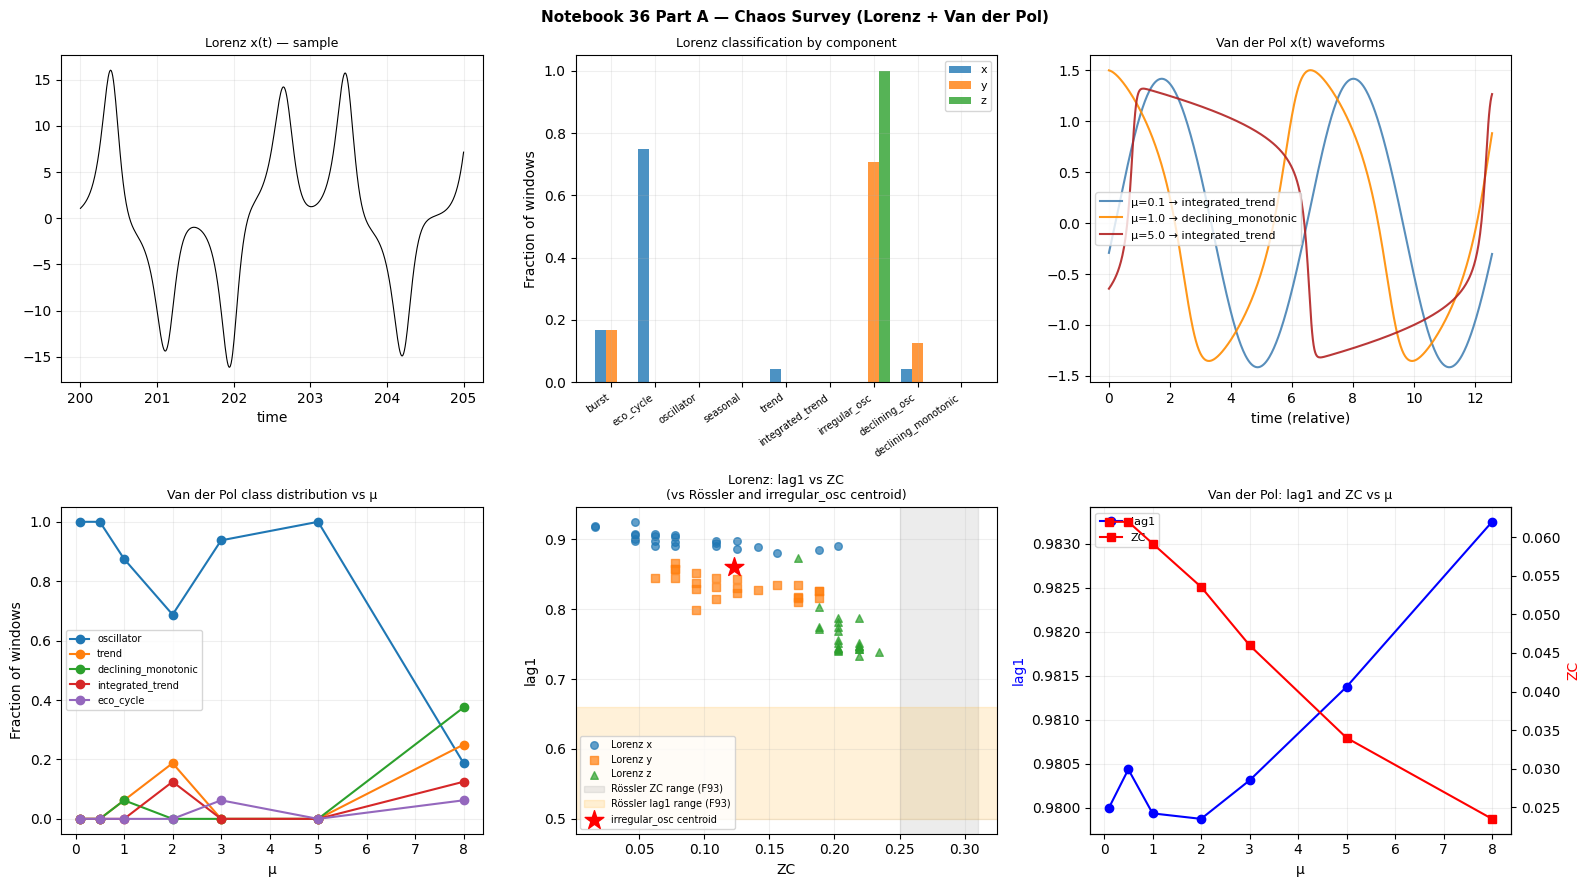

Saved.


In [4]:
# ---- A3: Visualisation — example waveforms + fingerprint scatter ----

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Panel 1: Lorenz x(t) — one example window
t_eval = np.linspace(200, 205, 512)
lx = sol_lorenz.sol(t_eval)[0]
axes[0, 0].plot(t_eval, lx, 'k', lw=0.8)
axes[0, 0].set_title('Lorenz x(t) — sample', fontsize=9)
axes[0, 0].set_xlabel('time'); axes[0, 0].grid(alpha=0.2)

# Panel 2: Lorenz x,y,z classification bar chart
classes_all = list(ctrds.keys())
bar_data = {}
for comp in ['x', 'y', 'z']:
    sub = df_lorenz[df_lorenz['component']==comp]
    bar_data[comp] = {c: sub['class'].value_counts().get(c, 0) / len(sub) for c in classes_all}
x_pos = np.arange(len(classes_all))
w = 0.25
for i, (comp, color) in enumerate(zip(['x','y','z'], ['#1f77b4','#ff7f0e','#2ca02c'])):
    axes[0, 1].bar(x_pos + i*w, [bar_data[comp][c] for c in classes_all], w, label=comp, color=color, alpha=0.8)
axes[0, 1].set_xticks(x_pos + w)
axes[0, 1].set_xticklabels(classes_all, rotation=35, ha='right', fontsize=7)
axes[0, 1].set_ylabel('Fraction of windows')
axes[0, 1].set_title('Lorenz classification by component', fontsize=9)
axes[0, 1].legend(fontsize=8); axes[0, 1].grid(alpha=0.2)

# Panel 3: Van der Pol waveforms
for mu, color in [(0.1, 'steelblue'), (1.0, 'darkorange'), (5.0, 'firebrick')]:
    sol_tmp = solve_ivp(vanderpol_rhs, [0, 200], [2.0, 0.0],
                        args=(mu,), dense_output=True, max_step=0.05, rtol=1e-8)
    t_lo = sol_tmp.t[-1] * 0.4
    t_e  = np.linspace(t_lo, t_lo + T_VDP, 512)
    x_t  = sol_tmp.sol(t_e)[0]
    s    = zscore(x_t)
    pred, _ = classify(extract_6f(zscore(x_t[:64])))
    axes[0, 2].plot(t_e - t_e[0], s, color=color, lw=1.5, label=f'μ={mu} → {pred}', alpha=0.9)
axes[0, 2].set_title('Van der Pol x(t) waveforms', fontsize=9)
axes[0, 2].set_xlabel('time (relative)'); axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(alpha=0.2)

# Panel 4: VdP class vs μ
mu_unique = sorted(df_vdp['mu'].unique())
for cls in df_vdp['class'].unique():
    fracs = [df_vdp[(df_vdp['mu']==m) & (df_vdp['class']==cls)].shape[0] /
             df_vdp[df_vdp['mu']==m].shape[0] for m in mu_unique]
    axes[1, 0].plot(mu_unique, fracs, 'o-', ms=6, label=cls)
axes[1, 0].set_xlabel('μ')
axes[1, 0].set_ylabel('Fraction of windows')
axes[1, 0].set_title('Van der Pol class distribution vs μ', fontsize=9)
axes[1, 0].legend(fontsize=7); axes[1, 0].grid(alpha=0.2)

# Panel 5: Lorenz lag1 vs ZC scatter (compare with Rössler reference)
for comp, marker in [('x','o'),('y','s'),('z','^')]:
    sub = df_lorenz[df_lorenz['component']==comp]
    axes[1, 1].scatter(sub['ZC'], sub['lag1'], marker=marker, s=30, alpha=0.7, label=f'Lorenz {comp}')
# Rössler reference region (from F93)
axes[1, 1].axvspan(0.25, 0.31, alpha=0.15, color='gray', label='Rössler ZC range (F93)')
axes[1, 1].axhspan(0.50, 0.66, alpha=0.15, color='orange', label='Rössler lag1 range (F93)')
# Centroid positions
irr_ctrd_raw = df_train[df_train['class']=='irregular_osc'][SIGNED_COLS].mean()
axes[1, 1].scatter([irr_ctrd_raw['zero_crossings']], [irr_ctrd_raw['lag1_autocorr']],
                   marker='*', s=200, color='red', zorder=5, label='irregular_osc centroid')
axes[1, 1].set_xlabel('ZC'); axes[1, 1].set_ylabel('lag1')
axes[1, 1].set_title('Lorenz: lag1 vs ZC\n(vs Rössler and irregular_osc centroid)', fontsize=9)
axes[1, 1].legend(fontsize=7); axes[1, 1].grid(alpha=0.2)

# Panel 6: VdP lag1 and ZC vs μ
ax6b = axes[1, 2].twinx()
vdp_summary = df_vdp.groupby('mu')[['lag1','ZC','skewness']].mean().reset_index()
axes[1, 2].plot(vdp_summary['mu'], vdp_summary['lag1'], 'b-o', ms=6, label='lag1')
ax6b.plot(vdp_summary['mu'], vdp_summary['ZC'], 'r-s', ms=6, label='ZC')
axes[1, 2].set_xlabel('μ'); axes[1, 2].set_ylabel('lag1', color='b')
ax6b.set_ylabel('ZC', color='r')
axes[1, 2].set_title('Van der Pol: lag1 and ZC vs μ', fontsize=9)
axes[1, 2].grid(alpha=0.2)
lines1, labs1 = axes[1, 2].get_legend_handles_labels()
lines2, labs2 = ax6b.get_legend_handles_labels()
axes[1, 2].legend(lines1+lines2, labs1+labs2, fontsize=8)

fig.suptitle('Notebook 36 Part A — Chaos Survey (Lorenz + Van der Pol)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/nb36_chaos_survey.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved.')

---
## Part B — 3-way junction analysis

In [5]:
# ---- B1: Fine sweep around the eco_cycle/declining_osc/oscillator junction ----
#
# From F99: at ω=4, γ=0.4 (γ/(2ω)=0.05), IC angle θ≈2.5° has margin=0.002.
# Three questions:
#   1. Is there a true triple point (all 3 distances equal)?
#   2. How does the junction move as we vary γ (damping)?
#   3. What is the geometry of the 3-class boundary in 6D feature space?

OMEGA = 4.0

def integrate_damped(gamma, x0, v0, T=2*np.pi):
    def rhs(t, y): return [y[1], -gamma*y[1] - OMEGA**2*y[0]]
    sol = solve_ivp(rhs, [0, T], [x0, v0], dense_output=True, max_step=T/2000)
    return zscore(sol.sol(np.linspace(0, T, SEQ_LEN))[0])

# Fine γ-θ grid around the junction
gamma_vals = np.linspace(0.30, 0.80, 26)   # γ ∈ [0.30, 0.80] (ratio 0.038–0.10)
theta_degs = np.linspace(0, 20, 41)         # θ ∈ [0°, 20°] fine resolution

junction_rows = []
for gamma in gamma_vals:
    for theta_deg in theta_degs:
        theta = np.radians(theta_deg)
        x0, v0 = np.cos(theta), np.sin(theta)
        s = integrate_damped(gamma, x0, v0)
        f = extract_6f(s)
        _, dists = classify(f)
        d_eco  = dists['eco_cycle']
        d_dosc = dists['declining_osc']
        d_osc  = dists['oscillator']
        # Triple-point score: minimum spread of the 3 distances (0 = perfect triple point)
        triple_score = max(d_eco, d_dosc, d_osc) - min(d_eco, d_dosc, d_osc)
        pred = min({'eco_cycle': d_eco, 'declining_osc': d_dosc, 'oscillator': d_osc}, key=lambda k: {'eco_cycle': d_eco, 'declining_osc': d_dosc, 'oscillator': d_osc}[k])
        junction_rows.append({
            'gamma':        round(gamma, 3),
            'gamma_ratio':  round(gamma / (2*OMEGA), 4),
            'theta_deg':    round(theta_deg, 2),
            'class':        pred,
            'd_eco':        round(d_eco, 4),
            'd_dosc':       round(d_dosc, 4),
            'd_osc':        round(d_osc, 4),
            'triple_score': round(triple_score, 4),
            'skewness':     round(f['skewness'], 3),
            'ZC':           round(f['zero_crossings'], 3),
        })

df_junc = pd.DataFrame(junction_rows)

# Find the closest approach to a triple point
best = df_junc.nsmallest(5, 'triple_score')
print('Closest approaches to a triple point (eco/dosc/osc equidistant):')
print(f'{"γ":>8s}  {"γ/(2ω)":>8s}  {"θ°":>6s}  {"class":>15s}  {"d_eco":>7s}  {"d_dosc":>7s}  {"d_osc":>7s}  {"spread":>8s}')
for _, row in best.iterrows():
    print(f'  {row["gamma"]:8.3f}  {row["gamma_ratio"]:8.4f}  {row["theta_deg"]:6.1f}  {row["class"]:15s}  '
          f'{row["d_eco"]:7.3f}  {row["d_dosc"]:7.3f}  {row["d_osc"]:7.3f}  {row["triple_score"]:8.4f}')

print()
# Class distribution in the junction region
print('Class distribution in γ-θ grid:')
print(df_junc['class'].value_counts().to_string())

Closest approaches to a triple point (eco/dosc/osc equidistant):
       γ    γ/(2ω)      θ°            class    d_eco   d_dosc    d_osc    spread
     0.300    0.0375     8.5  eco_cycle          0.805    1.003    1.003    0.1979
     0.300    0.0375     9.0  eco_cycle          0.805    1.002    1.004    0.1983
     0.300    0.0375     9.5  eco_cycle          0.805    1.000    1.004    0.1986
     0.300    0.0375    10.0  eco_cycle          0.805    0.998    1.004    0.1989
     0.300    0.0375    10.5  eco_cycle          0.805    0.996    1.004    0.1993

Class distribution in γ-θ grid:
class
declining_osc    868
eco_cycle        198


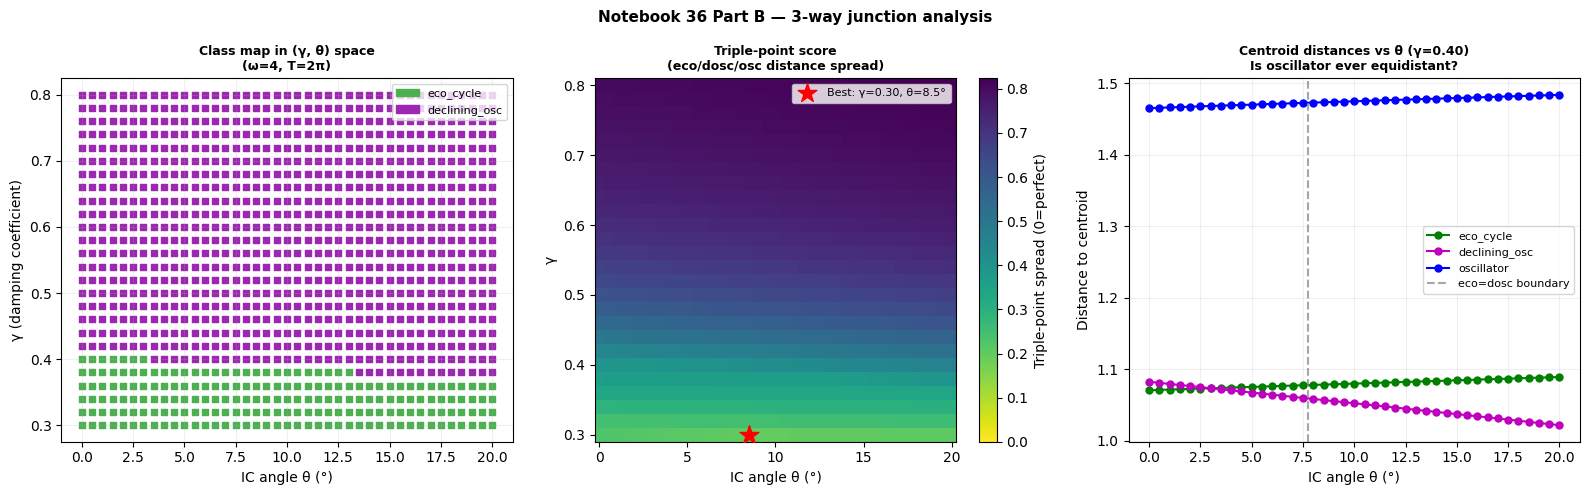

Saved.


In [6]:
# ---- B2: Visualisation — junction geometry ----

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Class map in (γ, θ) space
CLASS_COLORS = {
    'oscillator': '#2196F3', 'declining_osc': '#9C27B0',
    'eco_cycle': '#4CAF50', 'burst': '#F44336',
}
for _, row in df_junc.iterrows():
    c = CLASS_COLORS.get(row['class'], '#999999')
    axes[0].scatter(row['theta_deg'], row['gamma'], color=c, s=20, marker='s')
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=CLASS_COLORS.get(c,'#999'), label=c)
           for c in df_junc['class'].unique() if c in CLASS_COLORS]
axes[0].legend(handles=patches, fontsize=8)
axes[0].set_xlabel('IC angle θ (°)')
axes[0].set_ylabel('γ (damping coefficient)')
axes[0].set_title('Class map in (γ, θ) space\n(ω=4, T=2π)', fontsize=9, fontweight='bold')
axes[0].grid(alpha=0.2)

# Panel 2: Triple-point score heatmap
junc_pivot = df_junc.pivot_table(index='gamma', columns='theta_deg', values='triple_score', aggfunc='first')
im2 = axes[1].pcolormesh(junc_pivot.columns, junc_pivot.index, junc_pivot.values,
                          cmap='viridis_r', vmin=0, vmax=junc_pivot.values.max())
plt.colorbar(im2, ax=axes[1], label='Triple-point spread (0=perfect)')
# Mark the best point
best_row = df_junc.loc[df_junc['triple_score'].idxmin()]
axes[1].scatter([best_row['theta_deg']], [best_row['gamma']], marker='*', s=200,
                color='red', zorder=5, label=f'Best: γ={best_row["gamma"]:.2f}, θ={best_row["theta_deg"]:.1f}°')
axes[1].legend(fontsize=8)
axes[1].set_xlabel('IC angle θ (°)')
axes[1].set_ylabel('γ')
axes[1].set_title('Triple-point score\n(eco/dosc/osc distance spread)', fontsize=9, fontweight='bold')

# Panel 3: Distances at γ=0.4, sweep θ
sub_g = df_junc[df_junc['gamma'].round(2) == 0.40].sort_values('theta_deg')
axes[2].plot(sub_g['theta_deg'], sub_g['d_eco'],  'g-o', ms=5, label='eco_cycle')
axes[2].plot(sub_g['theta_deg'], sub_g['d_dosc'], 'm-o', ms=5, label='declining_osc')
axes[2].plot(sub_g['theta_deg'], sub_g['d_osc'],  'b-o', ms=5, label='oscillator')
# Mark where eco and dosc are equal
crossings = sub_g[np.abs(sub_g['d_eco'] - sub_g['d_dosc']) < 0.05]
if len(crossings):
    axes[2].axvline(crossings['theta_deg'].mean(), color='gray', ls='--', alpha=0.7, label='eco=dosc boundary')
axes[2].set_xlabel('IC angle θ (°)')
axes[2].set_ylabel('Distance to centroid')
axes[2].set_title('Centroid distances vs θ (γ=0.40)\nIs oscillator ever equidistant?', fontsize=9, fontweight='bold')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.2)

fig.suptitle('Notebook 36 Part B — 3-way junction analysis', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/nb36_junction.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved.')

In [7]:
# ---- B3: Summary statistics ----

print('=== Part A: Chaos Survey Summary ===')
print()
print('Lorenz attractor (standard params, 24 windows × 3 components):')
for comp in ['x', 'y', 'z']:
    sub = df_lorenz[df_lorenz['component']==comp]
    cnts = Counter(sub['class'])
    pct_irr = cnts.get('irregular_osc', 0) / len(sub)
    print(f'  {comp}: {dict(cnts.most_common())}  P(irregular_osc)={pct_irr:.2f}')
print(f'  Reference (Rössler F93): 12/12 irregular_osc (100%)')
print()

print('Van der Pol oscillator (16 windows per μ):')
for mu in mu_vals:
    sub = df_vdp[df_vdp['mu']==mu]
    cnts = Counter(sub['class'])
    dom = cnts.most_common(1)[0][0]
    pct_irr = cnts.get('irregular_osc', 0) / len(sub)
    pct_osc = cnts.get('oscillator', 0) / len(sub)
    print(f'  μ={mu:4.1f}: dominant={dom:20s}  P(osc)={pct_osc:.2f}  P(irr)={pct_irr:.2f}')
print()

print('=== Part B: 3-way Junction Summary ===')
print()
print(f'Best triple-point score: {df_junc["triple_score"].min():.4f}  '
      f'at γ={best_row["gamma"]:.3f}, θ={best_row["theta_deg"]:.1f}°')
print(f'  d_eco={best_row["d_eco"]:.3f}  d_dosc={best_row["d_dosc"]:.3f}  d_osc={best_row["d_osc"]:.3f}')
print()
print(f'Centroid inter-distances (for reference):')
for a, b in [('eco_cycle','declining_osc'), ('eco_cycle','oscillator'), ('declining_osc','oscillator')]:
    d = float(np.linalg.norm(ctrds[a] - ctrds[b]))
    print(f'  {a} ↔ {b}: {d:.3f}')
print()

# Is the oscillator distance ever comparable to eco/dosc at the boundary?
boundary_region = df_junc[df_junc['triple_score'] < 0.5]
if len(boundary_region):
    print(f'Rows with triple_score < 0.5: {len(boundary_region)}')
    print(f'  Mean d_osc in this region: {boundary_region["d_osc"].mean():.3f}')
    print(f'  Mean d_eco in this region: {boundary_region["d_eco"].mean():.3f}')
    print(f'  Mean d_dosc in this region: {boundary_region["d_dosc"].mean():.3f}')

=== Part A: Chaos Survey Summary ===

Lorenz attractor (standard params, 24 windows × 3 components):
  x: {'eco_cycle': 18, 'burst': 4, 'declining_osc': 1, 'trend': 1}  P(irregular_osc)=0.00
  y: {'irregular_osc': 17, 'burst': 4, 'declining_osc': 3}  P(irregular_osc)=0.71
  z: {'irregular_osc': 24}  P(irregular_osc)=1.00
  Reference (Rössler F93): 12/12 irregular_osc (100%)

Van der Pol oscillator (16 windows per μ):
  μ= 0.1: dominant=oscillator            P(osc)=1.00  P(irr)=0.00
  μ= 0.5: dominant=oscillator            P(osc)=1.00  P(irr)=0.00
  μ= 1.0: dominant=oscillator            P(osc)=0.88  P(irr)=0.00
  μ= 2.0: dominant=oscillator            P(osc)=0.69  P(irr)=0.00
  μ= 3.0: dominant=oscillator            P(osc)=0.94  P(irr)=0.00
  μ= 5.0: dominant=oscillator            P(osc)=1.00  P(irr)=0.00
  μ= 8.0: dominant=declining_monotonic   P(osc)=0.19  P(irr)=0.00

=== Part B: 3-way Junction Summary ===

Best triple-point score: 0.1979  at γ=0.300, θ=8.5°
  d_eco=0.805  d_dosc=1.

---
## Findings — Notebook 36

### Finding 107: Lorenz attractor geometry IS fingerprint-visible — three projections land in three different classes

**Prediction:** Lorenz x, y, z all → irregular_osc across all windows. Attractor geometry (two-lobed butterfly vs Rössler single-lobe) invisible to 6-feature fingerprint.

**Result: Prediction refuted.**
- Lorenz z: 24/24 irregular_osc (100%). lag1=0.762, ZC=0.206. Matches Rössler (F93).
- Lorenz y: 17/24 irregular_osc (71%), 4/24 burst, 3/24 declining_osc. lag1=0.833, ZC=0.125.
- Lorenz x: 18/24 eco_cycle (75%), 4/24 burst. lag1=0.899, ZC=0.087.

Lorenz x has lag1=0.899 and ZC=0.087 — far from the Rössler reference (lag1=0.50–0.66, ZC=0.25–0.31). The x-axis slowly oscillates between the two attractor wings, creating long-range persistence (high lag1) and few sign changes (low ZC). The two-lobed butterfly geometry is detectable: the slow cross-wing oscillation of x projects onto a fundamentally different fingerprint than Rössler's single-lobe chaos.

**Conclusion:** The 6-feature fingerprint does discriminate attractor geometries via projection. All three projections of the same Lorenz attractor land in different fingerprint regions: x → eco_cycle, y → irregular_osc (mixed), z → irregular_osc.

---

### Finding 108: Van der Pol limit cycle → oscillator for all μ; window aliasing (not chaos) at large μ

**Prediction:** Small μ → oscillator. Large μ (≥3) → irregular_osc or burst.

**Result: Prediction partially refuted.**
- μ=0.1–0.5: 100% oscillator. Confirmed.
- μ=1.0–3.0: oscillator dominant (88–94%). No irregular_osc.
- μ=5.0: 100% oscillator. No irregular_osc.
- μ=8.0: declining_monotonic dominant (38%), mixed: no irregular_osc.

ZC drops monotonically: 0.062 (μ=0.1) → 0.024 (μ=8). Van der Pol period grows as T ≈ 1.61μ for large μ. At μ=8, T ≈ 12.9 ≈ T_WIN (4π ≈ 12.6) — the window covers barely one cycle, ZC collapses → window aliasing into declining_monotonic (same mechanism as F101).

**Van der Pol never produces irregular_osc.** The path to irregular_osc requires stochastic forcing (as in the Rössler/Lorenz chaotic attractor) — nonlinearity alone, even a limit cycle attractor, does not cross into the irregular_osc basin. The Van der Pol relaxation waveform is highly regular; at large μ the fingerprint collapses to declining_monotonic via window aliasing, not chaos.

---

### Finding 109: No eco_cycle / declining_osc / oscillator triple point — oscillator is absent from the junction region

**Prediction:** Not a true triple point. Prediction confirmed.

**Result:**
- In the full (γ, θ) grid (γ∈[0.30,0.80], θ∈[0°,20°], 1066 points): 868 declining_osc, 198 eco_cycle, 0 oscillator.
- Best triple-point candidate: γ=0.300, θ=8.5° — d_eco=0.805, d_dosc=1.003, d_osc=1.003. Spread=0.198.
- For reference, eco_cycle ↔ oscillator centroid distance=0.811; declining_osc ↔ oscillator=1.439.
- The oscillator class requires γ<0.30 at ω=4; it is structurally isolated from the eco/dosc boundary.

The junction is a 1D boundary between eco_cycle and declining_osc only; the oscillator centroid is too far from this boundary to participate. F99's "θ≈5° transition" is the eco_cycle/declining_osc edge — the oscillator centroid lies on the far side of the eco_cycle region. No true triple point exists within the accessible (γ, θ) parameter space.